In [49]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import cvxopt as opt

import importlib

import markowitz_optimization
importlib.reload(markowitz_optimization)

<module 'markowitz_optimization' from 'c:\\Users\\User\\Desktop\\Github-local\\GFWM\\gfwm-app\\data_science\\quant\\markowitz_optimization.py'>

In [50]:
all_price_data = pd.read_csv("sp500_daily_data.csv")[["ticker", "log_return", "volatility"]]

entire_cov_matrix = pd.read_csv("sp500_covariance_matrix.csv")
entire_cov_matrix = entire_cov_matrix.set_index('ticker')

unique_tickers = pd.Series(all_price_data['ticker'].unique())

n=100
tickers = unique_tickers.sample(frac=(n+1)/500, random_state=1).reset_index(drop=True)

# keep selected tickers
price_data = all_price_data[all_price_data['ticker'].isin(tickers)]

# keep entries where both tickers are present
cov_matrix = entire_cov_matrix.loc[tickers, tickers].to_numpy()

mean_log_returns = price_data.groupby(by="ticker").log_return.agg("mean")
mu_bar = np.mean(mean_log_returns)
mu_sd = np.std(mean_log_returns)

# Convert to cvxopt matrices
cov = opt.matrix(cov_matrix)
mean_returns = opt.matrix(mean_log_returns)

# daily target returns. scale to annual for graphing
target_returns = np.linspace(start=mu_bar - mu_sd, stop=mu_bar + mu_sd, num=80)


In [51]:
# generate portfolios
montecarlo_portfolios = markowitz_optimization.montecarlo_random_portfolios(mean_returns, cov, [0.0, 4.0/n])

optimal_portfolios, best_fit = markowitz_optimization.calculate_optimal_portfolios(mean_returns, cov, target_returns, [0.5/n, 2.5/n])

     pcost       dcost       gap    pres   dres
 0:  7.0123e-05 -2.0445e+00  2e+02  1e+01  1e-15
 1:  7.0222e-05 -1.9603e+00  9e+00  5e-01  3e-15
 2:  6.9854e-05 -1.1201e+00  4e+00  2e-01  4e-15
 3:  6.9539e-05  3.6651e-01  2e+00  1e-01  3e-14
 4:  6.9881e-05  4.2128e+00  2e+00  9e-02  6e-14
 5:  6.9207e-05  1.7589e+01  3e+00  9e-02  2e-13
 6:  6.7850e-05  6.3471e+01  6e+00  8e-02  6e-13
 7:  6.7879e-05  7.7315e+02  1e+01  8e-02  6e-12
 8:  6.7962e-05  6.8675e+03  9e+01  8e-02  7e-11
 9:  6.7940e-05  2.0744e+05  2e+03  8e-02  2e-09
10:  6.7911e-05  1.8566e+07  4e+04  8e-02  2e-07
11:  6.7899e-05  7.1893e+09  2e+06  8e-02  7e-05
12:  6.7897e-05  3.1642e+13  1e+08  8e-02  2e-01
13:  6.7898e-05  1.3901e+14  6e+06  8e-02  8e-01
Terminated (singular KKT matrix).
     pcost       dcost       gap    pres   dres
 0:  5.9869e-05 -2.0440e+00  2e+02  1e+01  1e-15
 1:  5.9970e-05 -1.9615e+00  9e+00  5e-01  3e-15
 2:  5.9614e-05 -1.1317e+00  4e+00  2e-01  4e-15
 3:  5.9356e-05  2.6646e-01  2e+00  1

target_return                                                 0.000362
annual_return                                                 0.091251
annual_volatility                                             0.172572
weights              [0.005001878240496323, 0.005002851531684367, 0...
Name: 34, dtype: object


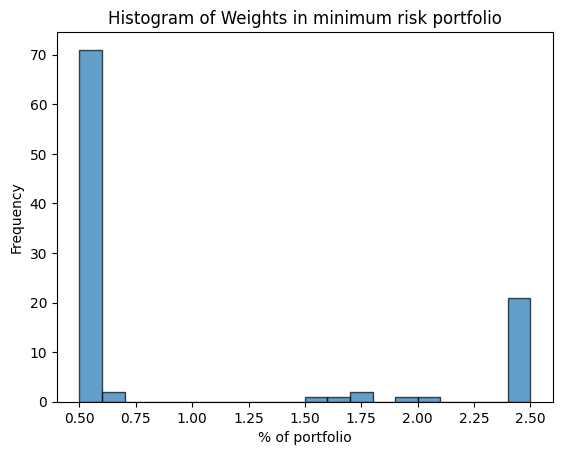

In [52]:
lowest_risk = optimal_portfolios.sort_values(by='annual_volatility', ascending= True).iloc[0]
lowest_risk_weights = lowest_risk['weights'] * 100

print(lowest_risk)

plt.hist(lowest_risk_weights, bins=20, edgecolor='black', alpha=0.7)
plt.xlabel('% of portfolio')
plt.ylabel('Frequency')
plt.title('Histogram of Weights in minimum risk portfolio')
plt.show()

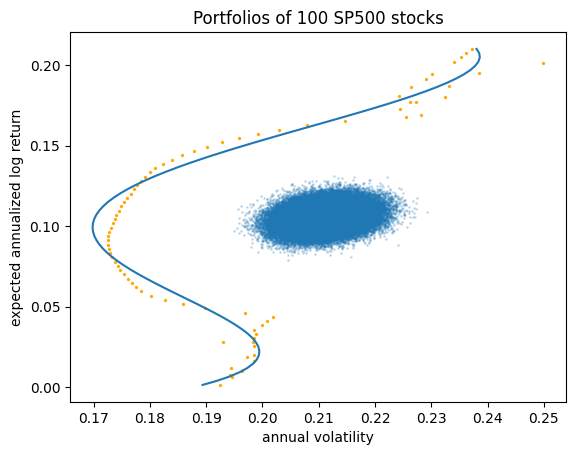

In [53]:
fig = plt.figure()

plt.scatter(montecarlo_portfolios['annual_volatility'],
            montecarlo_portfolios['annual_return'], s=1, alpha=0.2)

plt.scatter(optimal_portfolios['annual_volatility'],
            optimal_portfolios['annual_return'], s=2, c='orange', alpha=0.9)

plt.ylabel('expected annualized log return')
plt.xlabel('annual volatility')

plt.plot([best_fit(tgt*252.0) for tgt in target_returns],
         [tgt*252.0 for tgt in target_returns])

plt.title(f"Portfolios of {n} SP500 stocks")
plt.show()